# 📈 Bluestock MF Capstone — Fund Performance Analytics
**Day 4 | Performance Analytics**

Metrics computed:
- Daily Returns
- CAGR (1yr, 3yr, 5yr)
- Sharpe Ratio (Rf = 6.5%)
- Sortino Ratio
- Alpha & Beta (vs Nifty 100)
- Maximum Drawdown
- Fund Scorecard (0–100)
- Benchmark Comparison + Tracking Error

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

BASE_DIR  = Path().resolve().parent
RAW       = BASE_DIR / 'data' / 'raw'
PROCESSED = BASE_DIR / 'data' / 'processed'
REPORTS   = BASE_DIR / 'reports'
REPORTS.mkdir(exist_ok=True)

RF = 0.065 / 252  # Daily risk-free rate (RBI repo rate 6.5%)
TRADING_DAYS = 252

print('Setup complete')
print(f'BASE_DIR: {BASE_DIR}')

Setup complete
BASE_DIR: C:\Users\JK\bluestock_mf_capstone


In [2]:
# Load data
nav       = pd.read_csv(PROCESSED / 'nav_clean.csv', parse_dates=['date'])
perf      = pd.read_csv(PROCESSED / 'performance_clean.csv')
bench     = pd.read_csv(RAW / '10_benchmark_indices.csv', parse_dates=['date'])
fund_master = pd.read_csv(RAW / '01_fund_master.csv')
fund_master.columns = fund_master.columns.str.strip().str.lower()
perf.columns = perf.columns.str.strip().str.lower()

print(f'NAV shape: {nav.shape}')
print(f'Funds: {nav["amfi_code"].nunique()}')
print(f'Date range: {nav["date"].min()} → {nav["date"].max()}')
print(f'Benchmark indices: {bench["index_name"].unique()}')

NAV shape: (46000, 3)
Funds: 40
Date range: 2022-01-03 00:00:00 → 2026-05-29 00:00:00
Benchmark indices: <StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str


## Task 1 — Daily Returns

Daily returns shape: (1149, 40)

Sample stats:
count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
dtype: float64


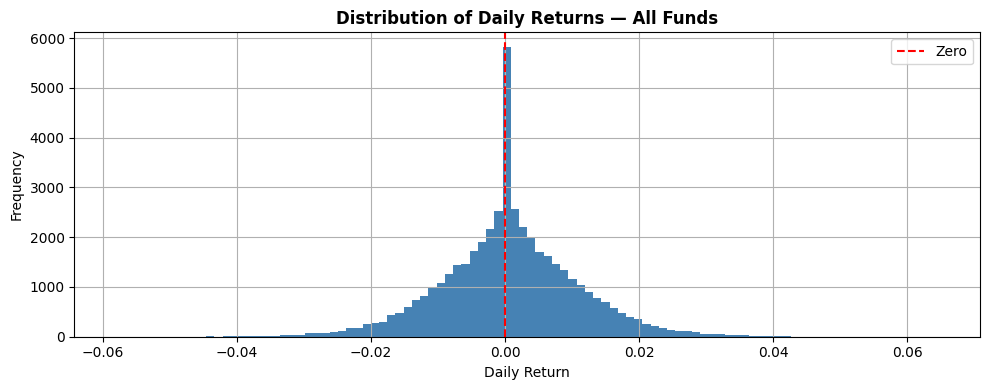

Chart saved


In [21]:
# Pivot NAV to wide format
nav_pivot = nav.pivot_table(index='date', columns='amfi_code', values='nav')
nav_pivot = nav_pivot.sort_index()

# Daily returns
daily_returns = nav_pivot.pct_change().dropna(how='all')

print(f'Daily returns shape: {daily_returns.shape}')
print(f'\nSample stats:')
print(daily_returns.stack().describe())

# Distribution plot
plt.figure(figsize=(10, 4))
daily_returns.stack().hist(bins=100, color='steelblue', edgecolor='none')
plt.title('Distribution of Daily Returns — All Funds', fontweight='bold')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.axvline(0, color='red', linestyle='--', label='Zero')
plt.legend()
plt.tight_layout()
plt.savefig(REPORTS / 'perf_chart1_daily_returns_dist.png', dpi=150)
plt.show()
print('Chart saved')

## Task 2 — CAGR (1yr, 3yr, 5yr)

In [4]:
def compute_cagr(nav_series, years):
    """Compute CAGR using actual trading days."""
    nav_series = nav_series.dropna()
    if len(nav_series) < 2:
        return np.nan
    end_date = nav_series.index.max()
    start_date = end_date - pd.DateOffset(years=years)
    series_filtered = nav_series[nav_series.index >= start_date]
    if len(series_filtered) < 2:
        return np.nan
    nav_start = series_filtered.iloc[0]
    nav_end   = series_filtered.iloc[-1]
    n_days    = len(series_filtered)
    n_years   = n_days / TRADING_DAYS
    return (nav_end / nav_start) ** (1 / n_years) - 1

cagr_records = []
for code in nav_pivot.columns:
    s = nav_pivot[code].dropna()
    cagr_records.append({
        'amfi_code': code,
        'cagr_1y':   compute_cagr(s, 1),
        'cagr_3y':   compute_cagr(s, 3),
        'cagr_5y':   compute_cagr(s, 5),
    })

cagr_df = pd.DataFrame(cagr_records)
cagr_df = cagr_df.merge(fund_master[['amfi_code','scheme_name','category']], on='amfi_code', how='left')

# Format as percentage
for col in ['cagr_1y','cagr_3y','cagr_5y']:
    cagr_df[col] = (cagr_df[col] * 100).round(2)

print('Top 10 funds by 3Y CAGR:')
print(cagr_df[['scheme_name','cagr_1y','cagr_3y','cagr_5y']].sort_values('cagr_3y', ascending=False).head(10).to_string(index=False))

Top 10 funds by 3Y CAGR:
                                       scheme_name  cagr_1y  cagr_3y  cagr_5y
               Axis Midcap Fund - Regular - Growth    21.33    33.62    27.08
     Mirae Asset Large Cap Fund - Regular - Growth    19.51    32.56    29.71
         ICICI Pru Bluechip Fund - Direct - Growth    12.54    31.12    22.37
HDFC Mid-Cap Opportunities Fund - Regular - Growth    50.76    31.07    28.90
          ICICI Pru Midcap Fund - Regular - Growth    28.33    30.44    31.48
         SBI Bluechip Fund - Regular Plan - Growth    57.57    29.18    24.77
            Kotak Flexicap Fund - Regular - Growth    25.52    28.35    29.65
     Mirae Asset Tax Saver Fund - Regular - Growth    37.98    27.96    30.64
     ABSL Frontline Equity Fund - Regular - Growth    45.73    27.76    22.60
             DSP Small Cap Fund - Regular - Growth    62.01    25.88    30.97


## Task 3 — Sharpe Ratio

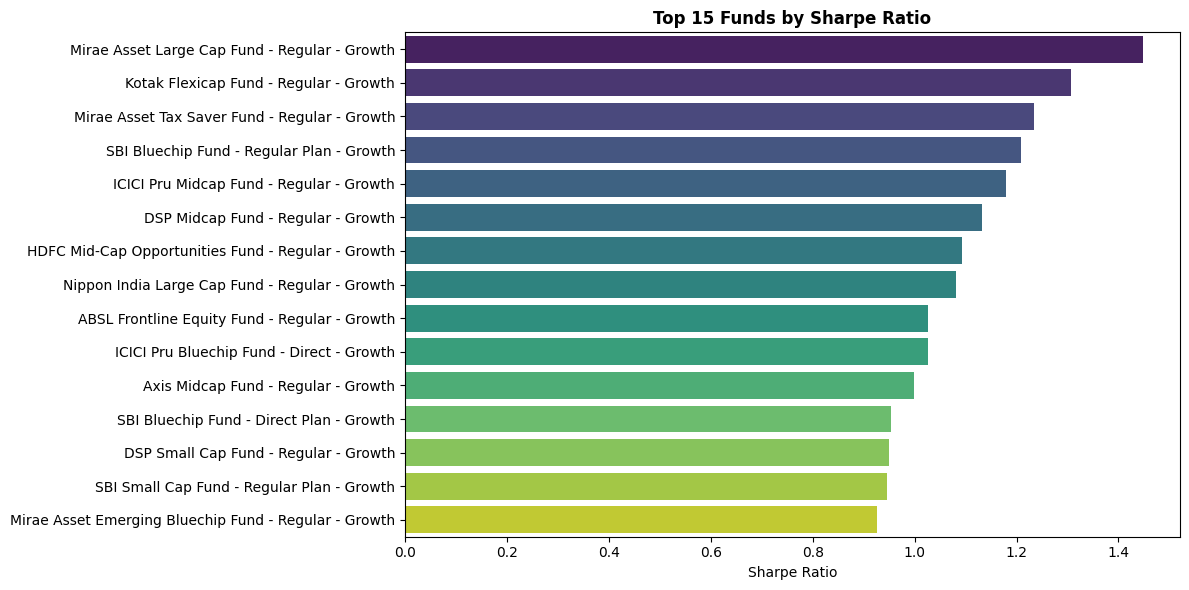

Sharpe chart saved
                                       scheme_name  sharpe_ratio
     Mirae Asset Large Cap Fund - Regular - Growth      1.448291
            Kotak Flexicap Fund - Regular - Growth      1.306744
     Mirae Asset Tax Saver Fund - Regular - Growth      1.234930
         SBI Bluechip Fund - Regular Plan - Growth      1.208267
          ICICI Pru Midcap Fund - Regular - Growth      1.180101
                DSP Midcap Fund - Regular - Growth      1.132122
HDFC Mid-Cap Opportunities Fund - Regular - Growth      1.093699
    Nippon India Large Cap Fund - Regular - Growth      1.081659
     ABSL Frontline Equity Fund - Regular - Growth      1.027213
         ICICI Pru Bluechip Fund - Direct - Growth      1.026524


In [22]:
def compute_sharpe(returns_series):
    r = returns_series.dropna()
    if len(r) < 30:
        return np.nan
    excess = r - RF
    return (excess.mean() / excess.std()) * np.sqrt(TRADING_DAYS)

sharpe_records = []
for code in daily_returns.columns:
    sharpe_records.append({
        'amfi_code': code,
        'sharpe_ratio': compute_sharpe(daily_returns[code])
    })

sharpe_df = pd.DataFrame(sharpe_records)
sharpe_df = sharpe_df.merge(fund_master[['amfi_code','scheme_name','category']], on='amfi_code', how='left')
sharpe_df = sharpe_df.sort_values('sharpe_ratio', ascending=False)

# Chart
plt.figure(figsize=(12, 6))
top15 = sharpe_df.head(15)
sns.barplot(data=top15, x='sharpe_ratio', y='scheme_name', palette='viridis')
plt.title('Top 15 Funds by Sharpe Ratio', fontweight='bold')
plt.xlabel('Sharpe Ratio')
plt.ylabel('')
plt.tight_layout()
plt.savefig(REPORTS / 'perf_chart2_sharpe.png', dpi=150)
plt.show()
print('Sharpe chart saved')
print(sharpe_df[['scheme_name','sharpe_ratio']].head(10).to_string(index=False))

## Task 4 — Sortino Ratio

In [6]:
def compute_sortino(returns_series):
    r = returns_series.dropna()
    if len(r) < 30:
        return np.nan
    excess = r - RF
    downside = excess[excess < 0]
    if len(downside) == 0:
        return np.nan
    downside_std = np.sqrt((downside ** 2).mean())
    return (excess.mean() / downside_std) * np.sqrt(TRADING_DAYS)

sortino_records = []
for code in daily_returns.columns:
    sortino_records.append({
        'amfi_code': code,
        'sortino_ratio': compute_sortino(daily_returns[code])
    })

sortino_df = pd.DataFrame(sortino_records)
sortino_df = sortino_df.merge(fund_master[['amfi_code','scheme_name']], on='amfi_code', how='left')
sortino_df = sortino_df.sort_values('sortino_ratio', ascending=False)

print('Top 10 Funds by Sortino Ratio:')
print(sortino_df[['scheme_name','sortino_ratio']].head(10).to_string(index=False))

Top 10 Funds by Sortino Ratio:
                                       scheme_name  sortino_ratio
     Mirae Asset Large Cap Fund - Regular - Growth       1.462279
            Kotak Flexicap Fund - Regular - Growth       1.381878
     Mirae Asset Tax Saver Fund - Regular - Growth       1.302066
         SBI Bluechip Fund - Regular Plan - Growth       1.261529
          ICICI Pru Midcap Fund - Regular - Growth       1.239497
                DSP Midcap Fund - Regular - Growth       1.135350
HDFC Mid-Cap Opportunities Fund - Regular - Growth       1.121981
    Nippon India Large Cap Fund - Regular - Growth       1.105130
     ABSL Frontline Equity Fund - Regular - Growth       1.069352
               Axis Midcap Fund - Regular - Growth       1.049253


## Task 5 — Alpha & Beta (vs Nifty 100)

In [23]:
# Prepare benchmark returns
nifty100 = bench[bench['index_name'] == 'NIFTY100'][['date','close_value']].set_index('date').sort_index()
nifty100_returns = nifty100['close_value'].pct_change().dropna()
nifty100_returns.name = 'nifty100'

ab_records = []
for code in daily_returns.columns:
    fund_ret = daily_returns[code].dropna()
    combined = pd.concat([fund_ret, nifty100_returns], axis=1).dropna()
    combined.columns = ['fund', 'benchmark']
    if len(combined) < 60:
        ab_records.append({'amfi_code': code, 'alpha': np.nan, 'beta': np.nan, 'r_squared': np.nan})
        continue
    slope, intercept, r, p, se = stats.linregress(combined['benchmark'], combined['fund'])
    ab_records.append({
        'amfi_code': code,
        'beta': round(slope, 4),
        'alpha': round(intercept * TRADING_DAYS * 100, 4),  # annualised %
        'r_squared': round(r**2, 4)
    })

ab_df = pd.DataFrame(ab_records)
ab_df = ab_df.merge(fund_master[['amfi_code','scheme_name','category']], on='amfi_code', how='left')
ab_df = ab_df.sort_values('alpha', ascending=False)

# Save
ab_df.to_csv(PROCESSED / 'alpha_beta.csv', index=False)
print('alpha_beta.csv saved')
print(ab_df[['scheme_name','alpha','beta','r_squared']].head(10).to_string(index=False))

alpha_beta.csv saved
                                       scheme_name   alpha    beta  r_squared
        SBI Small Cap Fund - Regular Plan - Growth 30.3370 -0.0232     0.0001
             DSP Small Cap Fund - Regular - Growth 30.0579  0.0115     0.0000
          ICICI Pru Midcap Fund - Regular - Growth 29.2636  0.0005     0.0000
     Mirae Asset Tax Saver Fund - Regular - Growth 28.2704  0.0181     0.0002
            Kotak Flexicap Fund - Regular - Growth 27.3305 -0.0228     0.0003
HDFC Mid-Cap Opportunities Fund - Regular - Growth 27.1954  0.0051     0.0000
     Mirae Asset Large Cap Fund - Regular - Growth 26.9838  0.0237     0.0005
                DSP Midcap Fund - Regular - Growth 26.5986 -0.0025     0.0000
               Axis Midcap Fund - Regular - Growth 26.0767 -0.0663     0.0019
         SBI Bluechip Fund - Regular Plan - Growth 23.2010 -0.0318     0.0009


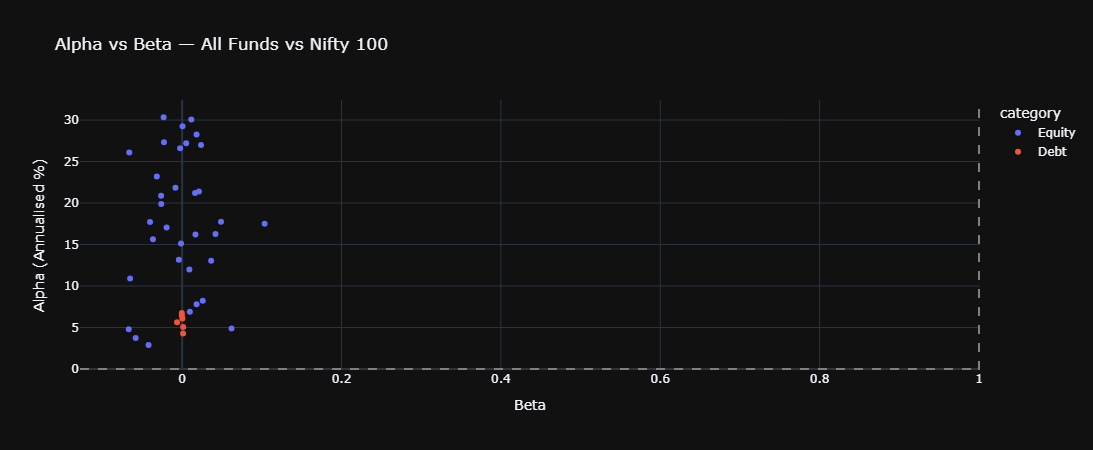

Alpha-Beta chart saved


In [24]:
# Alpha vs Beta scatter
fig = px.scatter(
    ab_df, x='beta', y='alpha', color='category',
    hover_data=['scheme_name'],
    title='Alpha vs Beta — All Funds vs Nifty 100',
    labels={'alpha': 'Alpha (Annualised %)', 'beta': 'Beta'},
    template='plotly_dark'
)
fig.add_hline(y=0, line_dash='dash', line_color='gray')
fig.add_vline(x=1, line_dash='dash', line_color='gray')
fig.update_layout(height=450)
fig.write_image(str(REPORTS / 'perf_chart3_alpha_beta.png'))
fig.show()
print('Alpha-Beta chart saved')

## Task 6 — Maximum Drawdown

In [9]:
def compute_max_drawdown(nav_series):
    s = nav_series.dropna()
    if len(s) < 2:
        return np.nan, None, None
    running_max = s.cummax()
    drawdown = s / running_max - 1
    max_dd = drawdown.min()
    end_date = drawdown.idxmin()
    # Find start date (peak before trough)
    start_date = s[:end_date].idxmax()
    return round(max_dd * 100, 2), start_date, end_date

dd_records = []
for code in nav_pivot.columns:
    max_dd, start, end = compute_max_drawdown(nav_pivot[code])
    dd_records.append({
        'amfi_code': code,
        'max_drawdown_pct': max_dd,
        'drawdown_start': start,
        'drawdown_end': end
    })

dd_df = pd.DataFrame(dd_records)
dd_df = dd_df.merge(fund_master[['amfi_code','scheme_name','category']], on='amfi_code', how='left')
dd_df = dd_df.sort_values('max_drawdown_pct')

print('Worst Drawdowns:')
print(dd_df[['scheme_name','max_drawdown_pct','drawdown_start','drawdown_end']].head(10).to_string(index=False))

Worst Drawdowns:
                                   scheme_name  max_drawdown_pct drawdown_start drawdown_end
     SBI Small Cap Fund - Direct Plan - Growth            -52.57     2023-01-17   2025-10-28
        Axis Small Cap Fund - Regular - Growth            -51.68     2025-05-22   2026-05-11
        ABSL Small Cap Fund - Regular - Growth            -35.45     2024-11-21   2026-05-11
         DSP Small Cap Fund - Regular - Growth            -31.17     2024-05-03   2025-01-03
    SBI Small Cap Fund - Regular Plan - Growth            -28.71     2024-08-28   2025-05-14
           UTI Mid Cap Fund - Regular - Growth            -28.00     2025-01-07   2026-04-27
     HDFC Top 100 Fund - Regular Plan - Growth            -24.73     2022-03-30   2022-09-15
 Kotak Emerging Equity Fund - Regular - Growth            -24.00     2023-11-09   2024-10-17
Nippon India Small Cap Fund - Regular - Growth            -23.34     2025-04-09   2026-02-20
          Axis Bluechip Fund - Direct - Growth       

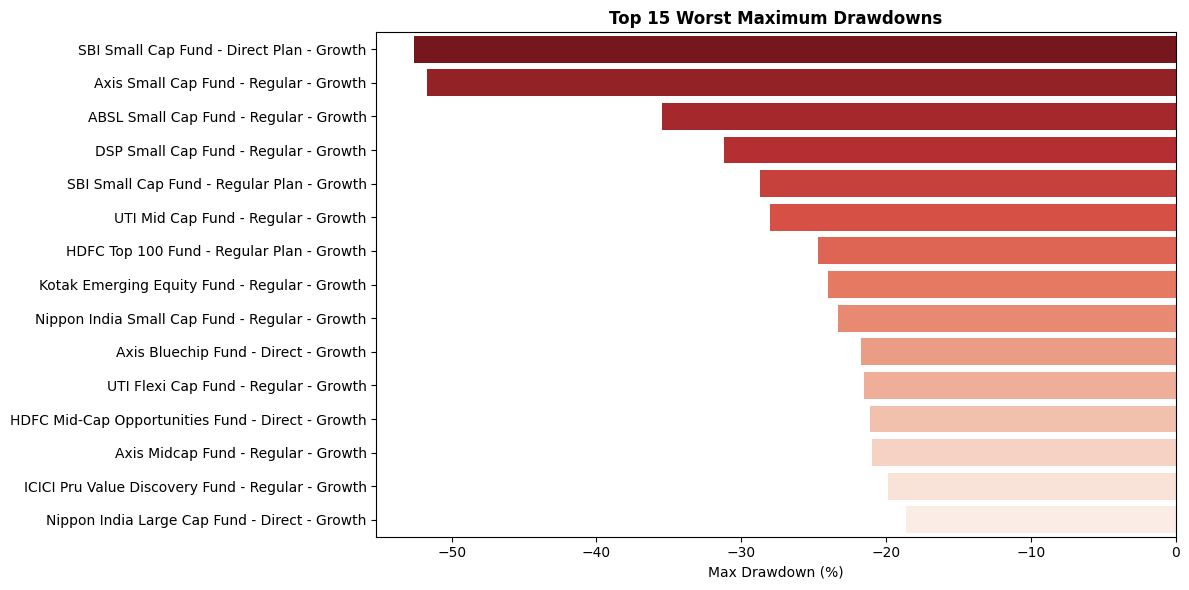

Drawdown chart saved


In [25]:
# Drawdown bar chart
plt.figure(figsize=(12, 6))
dd_plot = dd_df.head(15)
sns.barplot(data=dd_plot, x='max_drawdown_pct', y='scheme_name', palette='Reds_r')
plt.title('Top 15 Worst Maximum Drawdowns', fontweight='bold')
plt.xlabel('Max Drawdown (%)')
plt.ylabel('')
plt.tight_layout()
plt.savefig(REPORTS / 'perf_chart4_drawdown.png', dpi=150)
plt.show()
print('Drawdown chart saved')

## Task 7 — Fund Scorecard (0–100)

In [27]:
# Merge all metrics
scorecard = cagr_df[['amfi_code','scheme_name','category','cagr_3y']].copy()
scorecard = scorecard.merge(sharpe_df[['amfi_code','sharpe_ratio']], on='amfi_code', how='left')
scorecard = scorecard.merge(ab_df[['amfi_code','alpha']], on='amfi_code', how='left')
scorecard = scorecard.merge(dd_df[['amfi_code','max_drawdown_pct']], on='amfi_code', how='left')
scorecard = scorecard.merge(perf[['amfi_code','expense_ratio_pct']], on='amfi_code', how='left')

# Rank each metric
n = len(scorecard)
scorecard['rank_3y']      = scorecard['cagr_3y'].rank(ascending=True)      / n * 100
scorecard['rank_sharpe']  = scorecard['sharpe_ratio'].rank(ascending=True)  / n * 100
scorecard['rank_alpha']   = scorecard['alpha'].rank(ascending=True)         / n * 100
scorecard['rank_expense'] = scorecard['expense_ratio_pct'].rank(ascending=False) / n * 100  # inverse
scorecard['rank_dd']      = scorecard['max_drawdown_pct'].rank(ascending=False)  / n * 100  # inverse

# Composite score
scorecard['score'] = (
    0.30 * scorecard['rank_3y'] +
    0.25 * scorecard['rank_sharpe'] +
    0.20 * scorecard['rank_alpha'] +
    0.15 * scorecard['rank_expense'] +
    0.10 * scorecard['rank_dd']
).round(2)

scorecard = scorecard.sort_values('score', ascending=False)
scorecard.to_csv(PROCESSED / 'fund_scorecard.csv', index=False)
print('fund_scorecard.csv saved')
print(scorecard[['scheme_name','score','cagr_3y','sharpe_ratio','alpha']].head(10).to_string(index=False))

fund_scorecard.csv saved
                                       scheme_name  score  cagr_3y  sharpe_ratio   alpha
          ICICI Pru Midcap Fund - Regular - Growth  84.50    30.44      1.180101 29.2636
               Axis Midcap Fund - Regular - Growth  80.75    33.62      0.998231 26.0767
HDFC Mid-Cap Opportunities Fund - Regular - Growth  80.50    31.07      1.093699 27.1954
     Mirae Asset Large Cap Fund - Regular - Growth  80.00    32.56      1.448291 26.9838
            Kotak Flexicap Fund - Regular - Growth  78.25    28.35      1.306744 27.3305
         ICICI Pru Bluechip Fund - Direct - Growth  75.75    31.12      1.026524 21.1948
        SBI Small Cap Fund - Regular Plan - Growth  75.12    25.57      0.945308 30.3370
             DSP Small Cap Fund - Regular - Growth  74.94    25.88      0.949796 30.0579
     Mirae Asset Tax Saver Fund - Regular - Growth  73.94    27.96      1.234930 28.2704
         SBI Bluechip Fund - Regular Plan - Growth  73.06    29.18      1.208267 23.2

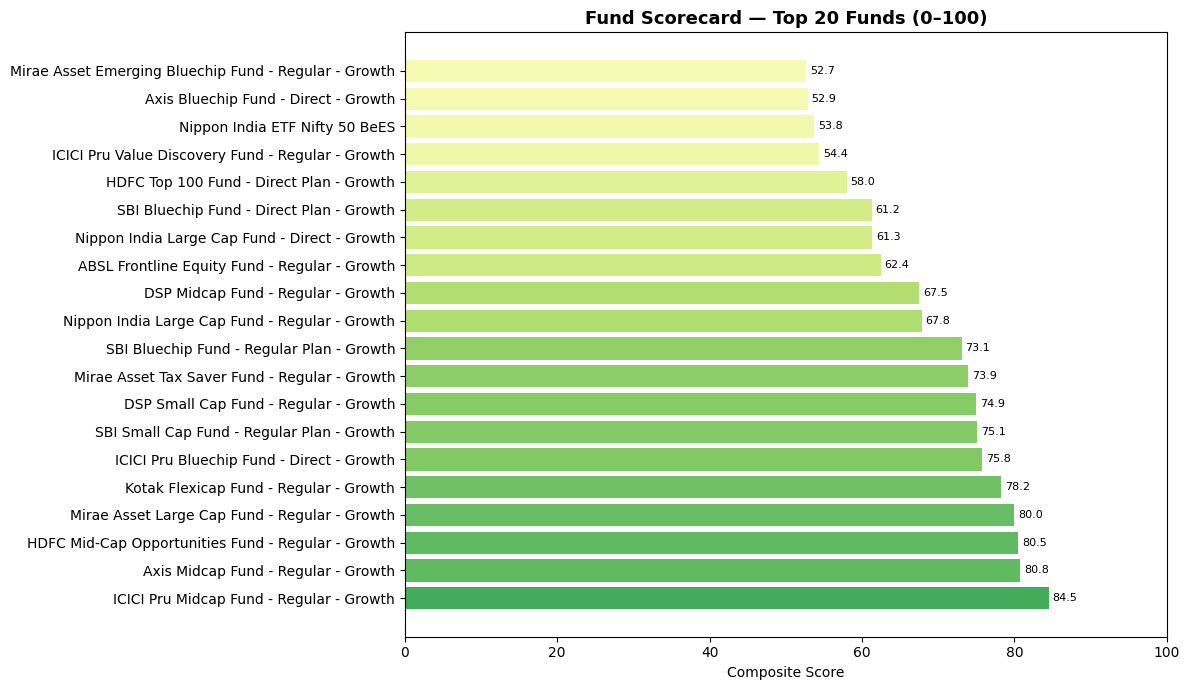

Scorecard chart saved


In [28]:
# Scorecard bar chart
plt.figure(figsize=(12, 7))
top20 = scorecard.head(20)
bars = plt.barh(top20['scheme_name'], top20['score'],
                color=plt.cm.RdYlGn(top20['score'] / 100))
plt.title('Fund Scorecard — Top 20 Funds (0–100)', fontweight='bold', fontsize=13)
plt.xlabel('Composite Score')
plt.xlim(0, 100)
for bar, score in zip(bars, top20['score']):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{score:.1f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(REPORTS / 'perf_chart5_scorecard.png', dpi=150)
plt.show()
print('Scorecard chart saved')

## Task 8 — Benchmark Comparison + Tracking Error

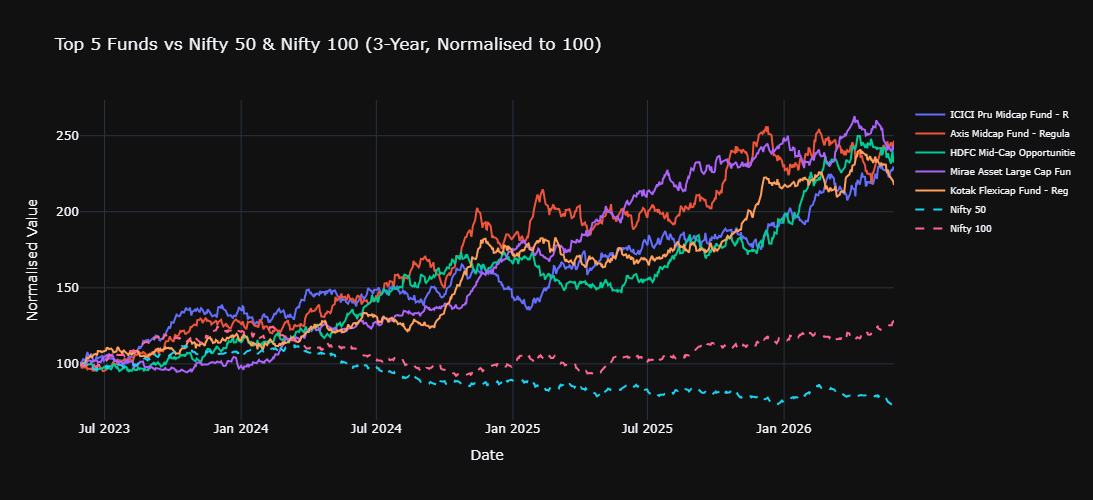

Benchmark chart saved


In [29]:
# Top 5 funds by scorecard
top5_codes = scorecard.head(5)['amfi_code'].tolist()
top5_names = scorecard.head(5).set_index('amfi_code')['scheme_name'].to_dict()

# Benchmark indices
nifty50  = bench[bench['index_name'] == 'NIFTY50'][['date','close_value']].set_index('date').sort_index()
nifty100 = bench[bench['index_name'] == 'NIFTY100'][['date','close_value']].set_index('date').sort_index()

# Filter to last 3 years
end_date   = nav['date'].max()
start_date = end_date - pd.DateOffset(years=3)

fig = go.Figure()

# Add top 5 fund NAVs (normalised to 100)
for code in top5_codes:
    s = nav_pivot[code].loc[start_date:end_date].dropna()
    s_norm = s / s.iloc[0] * 100
    fig.add_trace(go.Scatter(
        x=s_norm.index.strftime('%Y-%m-%d'),
        y=s_norm.values,
        name=top5_names[code][:25],
        mode='lines'
    ))

# Add benchmarks
for bname, bdf in [('Nifty 50', nifty50), ('Nifty 100', nifty100)]:
    b = bdf.loc[start_date:end_date]['close_value'].dropna()
    b_norm = b / b.iloc[0] * 100
    fig.add_trace(go.Scatter(
        x=b_norm.index.strftime('%Y-%m-%d'),
        y=b_norm.values,
        name=bname,
        mode='lines',
        line=dict(dash='dash', width=2)
    ))

fig.update_layout(
    title='Top 5 Funds vs Nifty 50 & Nifty 100 (3-Year, Normalised to 100)',
    xaxis_title='Date', yaxis_title='Normalised Value',
    template='plotly_dark', height=500,
    legend=dict(font=dict(size=9))
)
fig.write_image(str(REPORTS / 'perf_chart6_benchmark.png'))
fig.show()
print('Benchmark chart saved')

In [14]:
# Tracking Error vs Nifty 100
te_records = []
for code in top5_codes:
    fund_ret  = daily_returns[code].loc[start_date:end_date].dropna()
    bench_ret = nifty100_returns.loc[start_date:end_date].dropna()
    combined  = pd.concat([fund_ret, bench_ret], axis=1).dropna()
    combined.columns = ['fund', 'bench']
    te = (combined['fund'] - combined['bench']).std() * np.sqrt(TRADING_DAYS) * 100
    te_records.append({
        'fund': top5_names[code][:30],
        'tracking_error_pct': round(te, 2)
    })

te_df = pd.DataFrame(te_records)
print('Tracking Error vs Nifty 100:')
print(te_df.to_string(index=False))

Tracking Error vs Nifty 100:
                          fund  tracking_error_pct
ICICI Pru Midcap Fund - Regula               23.25
Axis Midcap Fund - Regular - G               23.97
HDFC Mid-Cap Opportunities Fun               22.48
Mirae Asset Large Cap Fund - R               18.79
Kotak Flexicap Fund - Regular                20.64


## Rolling 1-Year Returns

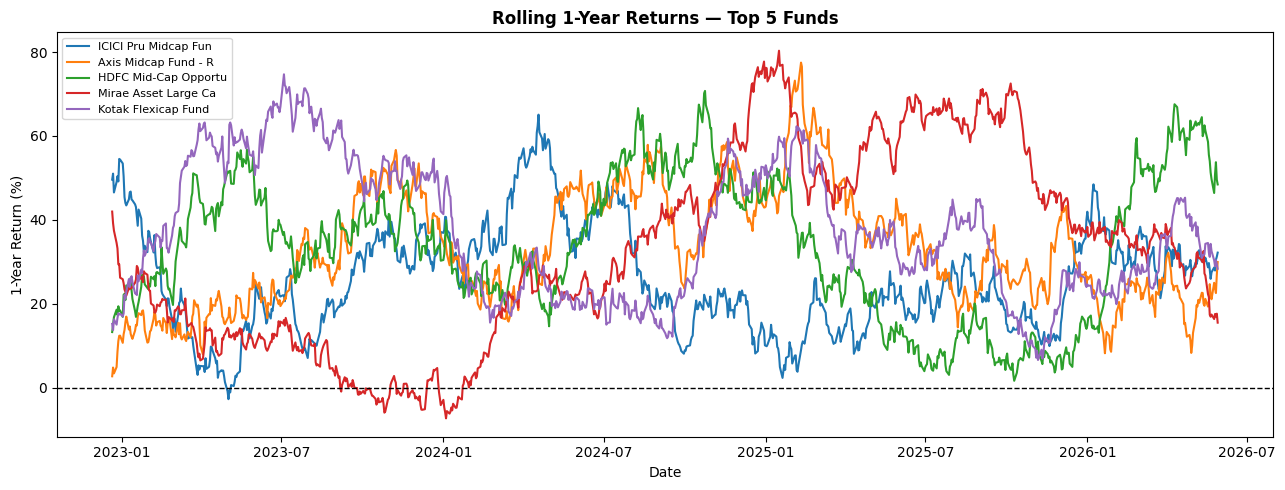

Rolling returns chart saved


In [30]:
# Rolling 252-day returns for top 5 funds
plt.figure(figsize=(13, 5))
for code in top5_codes:
    s = nav_pivot[code].dropna()
    rolling_ret = s.pct_change(TRADING_DAYS) * 100
    plt.plot(rolling_ret.index, rolling_ret.values,
             label=top5_names[code][:20], linewidth=1.5)

plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Rolling 1-Year Returns — Top 5 Funds', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('1-Year Return (%)')
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(REPORTS / 'perf_chart7_rolling_returns.png', dpi=150)
plt.show()
print('Rolling returns chart saved')

## CAGR Comparison Heatmap

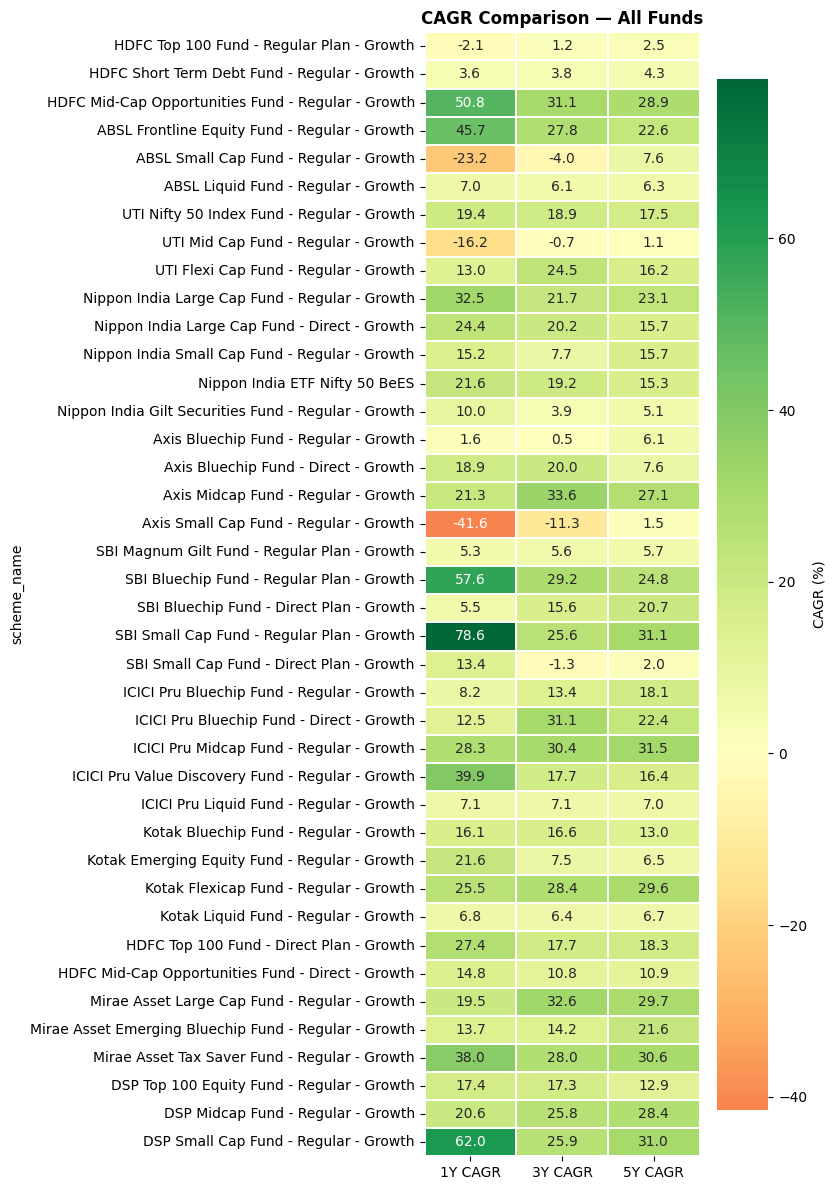

CAGR heatmap saved


In [31]:
cagr_heat = cagr_df[['scheme_name','cagr_1y','cagr_3y','cagr_5y']].dropna().set_index('scheme_name')
cagr_heat.columns = ['1Y CAGR','3Y CAGR','5Y CAGR']

plt.figure(figsize=(8, 12))
sns.heatmap(cagr_heat, annot=True, fmt='.1f', cmap='RdYlGn',
            center=0, linewidths=0.3, cbar_kws={'label': 'CAGR (%)'})
plt.title('CAGR Comparison — All Funds', fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS / 'perf_chart8_cagr_heatmap.png', dpi=150)
plt.show()
print('CAGR heatmap saved')

## Summary — All Deliverables

In [17]:
charts = list(REPORTS.glob('perf_chart*.png'))
print(f'Performance charts saved: {len(charts)}')
for c in sorted(charts):
    print(' ', c.name)

csvs = [PROCESSED / 'fund_scorecard.csv', PROCESSED / 'alpha_beta.csv']
print(f'\nCSV deliverables:')
for f in csvs:
    print(f'  {f.name} — {pd.read_csv(f).shape}')

print('\nDay 4 Complete!')

Performance charts saved: 8
  perf_chart1_daily_returns_dist.png
  perf_chart2_sharpe.png
  perf_chart3_alpha_beta.png
  perf_chart4_drawdown.png
  perf_chart5_scorecard.png
  perf_chart6_benchmark.png
  perf_chart7_rolling_returns.png
  perf_chart8_cagr_heatmap.png

CSV deliverables:
  fund_scorecard.csv — (40, 14)
  alpha_beta.csv — (40, 6)

✅ Day 4 Complete!
